### 1. 폰트 설정

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False
df_clean = pd.read_csv('../../data/df_clean.csv')
df_clean.columns = df_clean.columns.str.strip()

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

### 데이터 불러오기

In [39]:
df_clean.head()

,Product_Type,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,Clamping_Force,Cycle_Time,Pressure_Rise_Time,Casting_Pressure,Spray_Time,Spray_1_Time,Spray_2_Time,Melting_Furnace_Temp,Air_Pressure,Coolant_Temp,Coolant_Pressure,Factory_Temp,Factory_Humidity,Short_Shot_1,Bubble_1,Exfoliation_1,Blow_Hole_1,Stain_1,Dent_1,Deformation_1,Contamination_1,Impurity_1,Crack_1,Scratch_1,Buring_Mark_1,Inclusions_1,Short_Shot_2,Bubble_2,Exfoliation_2,Blow_Hole_2,Stain_2,Dent_2,Deformation_2,Contamination_2,Impurity_2,Crack_2,Scratch_2,Buring_Mark_2,Inclusions_2,Pressure_Difference,Pressure_Difference_Ratio,Velocity_2-1,Velocity_3-2,Velocity_High-3,Velocity_Max-Min,Defect_Status,Defect_Type
0,1,1,0.1440,0.1700,0.1880,2.1340,214,0.0080,10,258,20.7000,0.0440,1037,7.8000,0.7000,0.8000,695.0000,6.3000,26.0000,2.7100,32.9000,58.4000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,823,4.8458,0.0260,0.0180,1.9460,1.9900,0,Normal
1,1,2,0.1440,0.1700,0.1820,2.1240,217,0.0080,11,257,20.7000,0.0440,1052,7.8000,0.7000,0.8000,696.4000,6.3000,26.1000,2.6900,32.9000,58.2000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,835,4.8479,0.0260,0.0120,1.9420,1.9800,0,Normal
2,1,3,0.1440,0.1700,0.1820,2.1160,214,0.0080,11,257,20.8000,0.0410,1037,7.8000,0.7000,0.8000,696.4000,6.3000,26.1000,2.6900,32.9000,58.2000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,823,4.8458,0.0260,0.0120,1.9340,1.9720,0,Normal
3,1,4,0.1440,0.1700,0.1820,2.1370,217,0.0080,11,257,20.7000,0.0430,1051,7.8000,0.7000,0.8000,696.4000,6.3000,26.1000,2.6900,32.9000,58.2000,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,834,4.8433,0.0260,0.0120,1.9550,1.9930,1,Exfoliation
4,1,5,0.1440,0.1720,0.1760,2.1110,217,0.0080,12,257,20.7000,0.0420,1052,7.8000,0.7000,0.8000,697.9000,6.4000,26.1000,2.6900,32.9000,57.8000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,835,4.8479,0.0280,0.0040,1.9350,1.9670,0,Normal


In [40]:
df_clean['Defect_Type'].unique()

<StringArray>
[     'Normal', 'Exfoliation', 'Deformation',  'Short_Shot',       'Other',
       'Stain',      'Bubble',   'Blow_Hole']
Length: 8, dtype: str

In [41]:
type2_df = df_clean[df_clean['Product_Type'] == 2]
type2_df

,Product_Type,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,Clamping_Force,Cycle_Time,Pressure_Rise_Time,Casting_Pressure,Spray_Time,Spray_1_Time,Spray_2_Time,Melting_Furnace_Temp,Air_Pressure,Coolant_Temp,Coolant_Pressure,Factory_Temp,Factory_Humidity,Short_Shot_1,Bubble_1,Exfoliation_1,Blow_Hole_1,Stain_1,Dent_1,Deformation_1,Contamination_1,Impurity_1,Crack_1,Scratch_1,Buring_Mark_1,Inclusions_1,Short_Shot_2,Bubble_2,Exfoliation_2,Blow_Hole_2,Stain_2,Dent_2,Deformation_2,Contamination_2,Impurity_2,Crack_2,Scratch_2,Buring_Mark_2,Inclusions_2,Pressure_Difference,Pressure_Difference_Ratio,Velocity_2-1,Velocity_3-2,Velocity_High-3,Velocity_Max-Min,Defect_Status,Defect_Type
2651,2,11,0.1560,0.1660,0.1920,2.7230,265,0.0120,20,357,36.6000,0.0410,595,12.5000,2.0000,2.2000,671.6000,6.5000,26.1000,2.7000,33.2000,57.4000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,330,2.2453,0.0100,0.0260,2.5310,2.5670,0,Normal
2652,2,12,0.1570,0.1660,0.2040,2.7300,264,0.0140,19,359,36.5000,0.0400,594,12.5000,2.0000,2.2000,672.1000,6.4000,26.2000,2.7100,33.3000,57.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,330,2.2500,0.0090,0.0380,2.5260,2.5730,0,Normal
2653,2,13,0.1560,0.1700,0.2040,2.7150,265,0.0120,18,361,36.5000,0.0410,595,12.5000,2.0000,2.2000,672.4000,6.4000,26.2000,2.7000,33.5000,56.7000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,330,2.2453,0.0140,0.0340,2.5110,2.5590,0,Normal
2654,2,14,0.1540,0.1700,0.2020,2.7170,264,0.0110,20,364,36.5000,0.0420,595,12.5000,2.0000,2.2000,672.4000,6.4000,26.2000,2.7000,33.5000,56.7000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,331,2.2538,0.0160,0.0320,2.5150,2.5630,0,Normal
2655,2,15,0.1460,0.1600,0.1980,2.6840,264,0.0120,20,357,36.5000,0.0420,595,12.5000,2.0000,2.2000,672.4000,6.3000,26.2000,2.7100,33.6000,56.4000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,331,2.2538,0.0140,0.0380,2.4860,2.5380,0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4610,2,657,0.1440,0.1730,0.2000,2.5360,264,0.0120,17,381,36.3000,0.0360,595,12.1000,2.0000,2.0000,666.8000,6.7000,28.1000,2.6300,32.4000,69.3000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,331,2.2538,0.0290,0.0270,2.3360,2.3920,0,Normal
4611,2,658,0.1440,0.1730,0.2000,2.5360,264,0.0120,17,381,36.3000,0.0360,595,12.1000,2.0000,2.0000,667.4000,6.7000,28.1000,2.6200,32.3000,69.4000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,331,2.2538,0.0290,0.0270,2.3360,2.3920,0,Normal
4612,2,659,0.1500,0.1660,0.2100,2.4920,265,0.0110,17,381,36.2000,0.0330,595,12.1000,2.0000,2.0000,667.4000,6.7000,28.1000,2.6200,32.3000,69.4000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,330,2.2453,0.0160,0.0440,2.2820,2.3420,0,Normal
4613,2,660,0.1440,0.1740,0.2060,2.5140,264,0.0110,16,381,36.2000,0.0410,595,12.1000,2.0000,2.0000,667.8000,7.0000,28.1000,2.6200,32.2000,69.5000,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,331,2.2538,0.0300,0.0320,2.3080,2.3700,1,Blow_Hole


In [42]:
type2_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1964 entries, 2651 to 4614
Data columns (total 56 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Type               1964 non-null   int64  
 1   Shot                       1964 non-null   int64  
 2   Velocity_1                 1964 non-null   float64
 3   Velocity_2                 1964 non-null   float64
 4   Velocity_3                 1964 non-null   float64
 5   High_Velocity              1964 non-null   float64
 6   Cylinder_Pressure          1964 non-null   int64  
 7   Rapid_Rise_Time            1964 non-null   float64
 8   Biscuit_Thickness          1964 non-null   int64  
 9   Clamping_Force             1964 non-null   int64  
 10  Cycle_Time                 1964 non-null   float64
 11  Pressure_Rise_Time         1964 non-null   float64
 12  Casting_Pressure           1964 non-null   int64  
 13  Spray_Time                 1964 non-null   float64
 14  

In [43]:
type2_df.columns

Index(['Product_Type', 'Shot', 'Velocity_1', 'Velocity_2', 'Velocity_3',
       'High_Velocity', 'Cylinder_Pressure', 'Rapid_Rise_Time',
       'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time',
       'Pressure_Rise_Time', 'Casting_Pressure', 'Spray_Time', 'Spray_1_Time',
       'Spray_2_Time', 'Melting_Furnace_Temp', 'Air_Pressure', 'Coolant_Temp',
       'Coolant_Pressure', 'Factory_Temp', 'Factory_Humidity', 'Short_Shot_1',
       'Bubble_1', 'Exfoliation_1', 'Blow_Hole_1', 'Stain_1', 'Dent_1',
       'Deformation_1', 'Contamination_1', 'Impurity_1', 'Crack_1',
       'Scratch_1', 'Buring_Mark_1', 'Inclusions_1', 'Short_Shot_2',
       'Bubble_2', 'Exfoliation_2', 'Blow_Hole_2', 'Stain_2', 'Dent_2',
       'Deformation_2', 'Contamination_2', 'Impurity_2', 'Crack_2',
       'Scratch_2', 'Buring_Mark_2', 'Inclusions_2', 'Pressure_Difference',
       'Pressure_Difference_Ratio', 'Velocity_2-1', 'Velocity_3-2',
       'Velocity_High-3', 'Velocity_Max-Min', 'Defect_Status', 'Defect_Ty

[ 다중공선성 의심 변수 상관관계 ]


,Casting_Pressure,Cylinder_Pressure,Pressure_Difference,Pressure_Difference_Ratio
Casting_Pressure,1.0000,0.8810,0.9260,0.0540
Cylinder_Pressure,0.8810,1.0000,0.6370,-0.4240
Pressure_Difference,0.9260,0.6370,1.0000,0.4270
Pressure_Difference_Ratio,0.0540,-0.4240,0.4270,1.0000


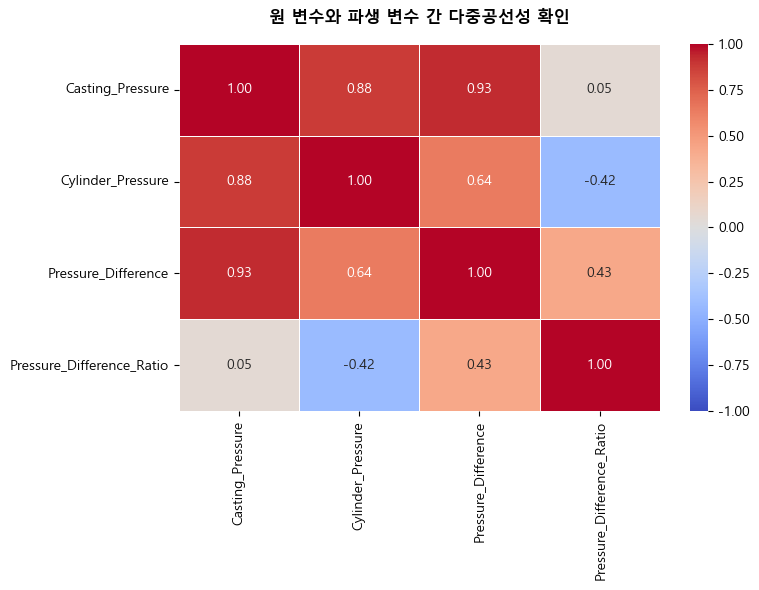

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

# 다중공선성 확인 — Casting_Pressure / Cylinder_Pressure / Pressure_Difference / Pressure_Difference_Ratio
high_corr_vars1 = ['Casting_Pressure', 'Cylinder_Pressure', 'Pressure_Difference', 'Pressure_Difference_Ratio']
print("[ 다중공선성 의심 변수 상관관계 ]")

# 상관계수 행렬 계산
corr_matrix = type2_df[high_corr_vars1].corr().round(3)
display(corr_matrix)

# -----------------
# 히트맵 시각화 추가
# -----------------
plt.figure(figsize=(8, 6)) # 히트맵 캔버스 크기 지정

# seaborn heatmap 생성
sns.heatmap(
    corr_matrix, 
    annot=True,            # 각 셀 안에 상관계수 숫자 표시
    cmap='coolwarm',       # 색상 팔레트 (파랑: 음의 상관관계, 빨강: 양의 상관관계)
    vmin=-1, vmax=1,       # 색상 표현 시 기준점 (-1 ~ 1)
    center=0,              # 중앙값을 0으로 맞춰 색상 대비 강조
    fmt='.2f',             # 숫자 표기 형식 (소수점 2자리)
    linewidths=0.5         # 셀 사이 경계선
)

plt.title('원 변수와 파생 변수 간 다중공선성 확인', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

[ 다중공선성 의심 변수 상관관계 ]


,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Velocity_2-1,Velocity_3-2,Velocity_High-3,Velocity_Max-Min
Velocity_1,1.0000,-0.0490,-0.0190,0.0120,-0.7770,0.0150,0.0130,-0.0440
Velocity_2,-0.0490,1.0000,-0.0200,-0.1670,0.6670,-0.6340,-0.1670,-0.1640
Velocity_3,-0.0190,-0.0200,1.0000,0.0890,0.0020,0.7850,0.0290,0.0900
High_Velocity,0.0120,-0.1670,0.0890,1.0000,-0.1140,0.1720,0.9980,0.9980
Velocity_2-1,-0.7770,0.6670,0.0020,-0.1140,1.0000,-0.4110,-0.1150,-0.0700
Velocity_3-2,0.0150,-0.6340,0.7850,0.1720,-0.4110,1.0000,0.1260,0.1710
Velocity_High-3,0.0130,-0.1670,0.0290,0.9980,-0.1150,0.1260,1.0000,0.9970
Velocity_Max-Min,-0.0440,-0.1640,0.0900,0.9980,-0.0700,0.1710,0.9970,1.0000


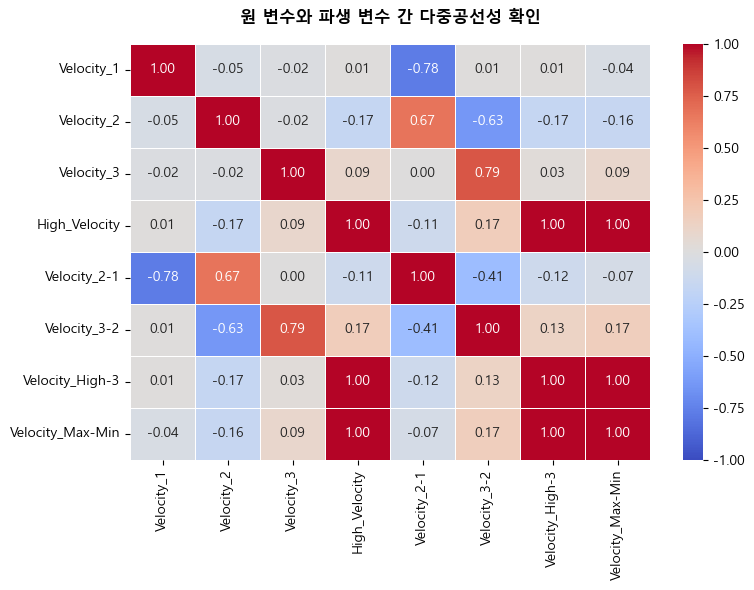

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# 다중공선성 확인 — Casting_Pressure / Cylinder_Pressure / Pressure_Difference / Pressure_Difference_Ratio
high_corr_vars2 = ['Velocity_1', 'Velocity_2', 'Velocity_3',
       'High_Velocity', 'Velocity_2-1', 'Velocity_3-2',
       'Velocity_High-3', 'Velocity_Max-Min']
print("[ 다중공선성 의심 변수 상관관계 ]")

# 상관계수 행렬 계산
corr_matrix = type2_df[high_corr_vars2].corr().round(3)
display(corr_matrix)

# -----------------
# 히트맵 시각화 추가
# -----------------
plt.figure(figsize=(8, 6)) # 히트맵 캔버스 크기 지정

# seaborn heatmap 생성
sns.heatmap(
    corr_matrix, 
    annot=True,            # 각 셀 안에 상관계수 숫자 표시
    cmap='coolwarm',       # 색상 팔레트 (파랑: 음의 상관관계, 빨강: 양의 상관관계)
    vmin=-1, vmax=1,       # 색상 표현 시 기준점 (-1 ~ 1)
    center=0,              # 중앙값을 0으로 맞춰 색상 대비 강조
    fmt='.2f',             # 숫자 표기 형식 (소수점 2자리)
    linewidths=0.5         # 셀 사이 경계선
)

plt.title('원 변수와 파생 변수 간 다중공선성 확인', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


### VIF 확인

In [46]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

high_corr_vars = ['Velocity_1', 'Velocity_2', 'Velocity_3','High_Velocity', ]

X = type2_df[high_corr_vars]

vif_df = pd.DataFrame()
vif_df["variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

display(vif_df)

,variable,VIF
0,Velocity_1,811.3880
1,Velocity_2,1027.6911
2,Velocity_3,1187.7442
3,High_Velocity,749.7849


In [47]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

high_corr_vars = ['Velocity_2-1', 'Velocity_3-2', 'Velocity_High-3', 'Velocity_Max-Min']

X = type2_df[high_corr_vars]

vif_df = pd.DataFrame()
vif_df["variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

display(vif_df)

,variable,VIF
0,Velocity_2-1,inf
1,Velocity_3-2,inf
2,Velocity_High-3,inf
3,Velocity_Max-Min,inf


In [48]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

high_corr_vars = ['Velocity_1', 'Velocity_2', 'Velocity_3','High_Velocity']

X = type2_df[high_corr_vars]

vif_df = pd.DataFrame()
vif_df["variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

display(vif_df)

,variable,VIF
0,Velocity_1,811.3880
1,Velocity_2,1027.6911
2,Velocity_3,1187.7442
3,High_Velocity,749.7849


In [49]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

high_corr_vars = ['Casting_Pressure', 'Cylinder_Pressure', 'Pressure_Difference', 'Pressure_Difference_Ratio']

X = type2_df[high_corr_vars]

vif_df = pd.DataFrame()
vif_df["variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

display(vif_df)

,variable,VIF
0,Casting_Pressure,inf
1,Cylinder_Pressure,inf
2,Pressure_Difference,inf
3,Pressure_Difference_Ratio,44.6042


In [50]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

high_corr_vars = ['Casting_Pressure', 'Cylinder_Pressure']

X = type2_df[high_corr_vars]

vif_df = pd.DataFrame()
vif_df["variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

display(vif_df)

,variable,VIF
0,Casting_Pressure,572985.2714
1,Cylinder_Pressure,572985.2714


In [51]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

high_corr_vars = ['Pressure_Difference', 'Pressure_Difference_Ratio']

X = type2_df[high_corr_vars]

vif_df = pd.DataFrame()
vif_df["variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

display(vif_df)

,variable,VIF
0,Pressure_Difference,155897.8746
1,Pressure_Difference_Ratio,155897.8746


In [52]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

high_corr_vars = ['Velocity_1', 'Velocity_2', 'Velocity_3','High_Velocity','Pressure_Difference_Ratio']

X = type2_df[high_corr_vars]

vif_df = pd.DataFrame()
vif_df["variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

display(vif_df)

,variable,VIF
0,Velocity_1,1029.0901
1,Velocity_2,1755.2390
2,Velocity_3,1590.2163
3,High_Velocity,951.6785
4,Pressure_Difference_Ratio,5773.3225


### 결함 컬럼들의 리스트와 마스킹

In [53]:
# 결함 컬럼들의 리스트
defect_columns = [
    'Short_Shot_1', 'Bubble_1', 'Exfoliation_1', 'Blow_Hole_1', 'Stain_1',
    'Dent_1', 'Deformation_1', 'Contamination_1', 'Impurity_1', 'Crack_1',
    'Scratch_1', 'Buring_Mark_1', 'Inclusions_1', 'Short_Shot_2',
    'Bubble_2', 'Exfoliation_2', 'Blow_Hole_2', 'Stain_2', 'Dent_2',
    'Deformation_2', 'Contamination_2', 'Impurity_2', 'Crack_2',
    'Scratch_2', 'Buring_Mark_2', 'Inclusions_2'
]

# 마스킹
has_defect = (type2_df[defect_columns] > 0).any(axis=1)

type2_df['Defect_Status'] = np.where(has_defect, 0, 1)

# 결과 확인
print(type2_df['Defect_Status'].value_counts())
print(type2_df['Defect_Status'].value_counts(normalize=True))

Defect_Status
1    1467
0     497
Name: count, dtype: int64
Defect_Status
1   0.7469
0   0.2531
Name: proportion, dtype: float64


In [54]:
import pandas as pd

defect_columns = [
    'Short_Shot_1', 'Bubble_1', 'Exfoliation_1', 'Blow_Hole_1', 'Stain_1',
    'Dent_1', 'Deformation_1', 'Contamination_1', 'Impurity_1', 'Crack_1',
    'Scratch_1', 'Buring_Mark_1', 'Inclusions_1', 'Short_Shot_2',
    'Bubble_2', 'Exfoliation_2', 'Blow_Hole_2', 'Stain_2', 'Dent_2',
    'Deformation_2', 'Contamination_2', 'Impurity_2', 'Crack_2',
    'Scratch_2', 'Buring_Mark_2', 'Inclusions_2'
]

# 추가로 제외할 컬럼
## Product type: Product type 기준 데이터 분리 후 필요 없는 컬럼
## Defect_Status: 독립변수에 해당하지 않음
## Defect_Type: 독립변수에 해당하지 않음

additional_excludes = ['Product_Type','Defect_Status', 'Defect_Type', 'Velocity_2-1','Velocity_3-2','Velocity_High-3','Velocity_Max-Min','Cylinder_Pressure','Casting_Pressure', 'Pressure_Difference']

# 두 리스트를 합쳐서 최종 제외 목록 생성
exclude_columns = defect_columns + additional_excludes

# 합쳐진 제외 목록을 기반으로 독립변수 컬럼 생성
independent_columns = [col for col in type2_df.columns if col not in exclude_columns]

X = type2_df[independent_columns] # 독립변수

print(f"독립변수 컬럼 개수: {len(independent_columns)}개")
print(independent_columns)

독립변수 컬럼 개수: 20개
['Shot', 'Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity', 'Rapid_Rise_Time', 'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time', 'Pressure_Rise_Time', 'Spray_Time', 'Spray_1_Time', 'Spray_2_Time', 'Melting_Furnace_Temp', 'Air_Pressure', 'Coolant_Temp', 'Coolant_Pressure', 'Factory_Temp', 'Factory_Humidity', 'Pressure_Difference_Ratio']


### 정규성 검정

In [55]:
from scipy import stats

results = []
for col in independent_columns:
    stat, p = stats.shapiro(type2_df[col].dropna())
    results.append({
        '변수': col,
        'W통계량': round(stat, 4),
        'p-value': f"{p:.5e}",
        '정규성': '✅' if p > 0.05 else '❌'
    })

display(pd.DataFrame(results))

,변수,W통계량,p-value,정규성
0,Shot,0.9633,6.34398e-22,❌
1,Velocity_1,0.9261,4.63534e-30,❌
2,Velocity_2,0.9685,2.56305e-20,❌
3,Velocity_3,0.9860,6.13940e-13,❌
4,High_Velocity,0.7260,5.78551e-49,❌
5,Rapid_Rise_Time,0.7695,3.37692e-46,❌
6,Biscuit_Thickness,0.9071,5.21268e-33,❌
7,Clamping_Force,0.8975,2.51917e-34,❌
8,Cycle_Time,0.2149,1.24566e-67,❌
9,Pressure_Rise_Time,0.8899,2.68248e-35,❌


### QQ Plot

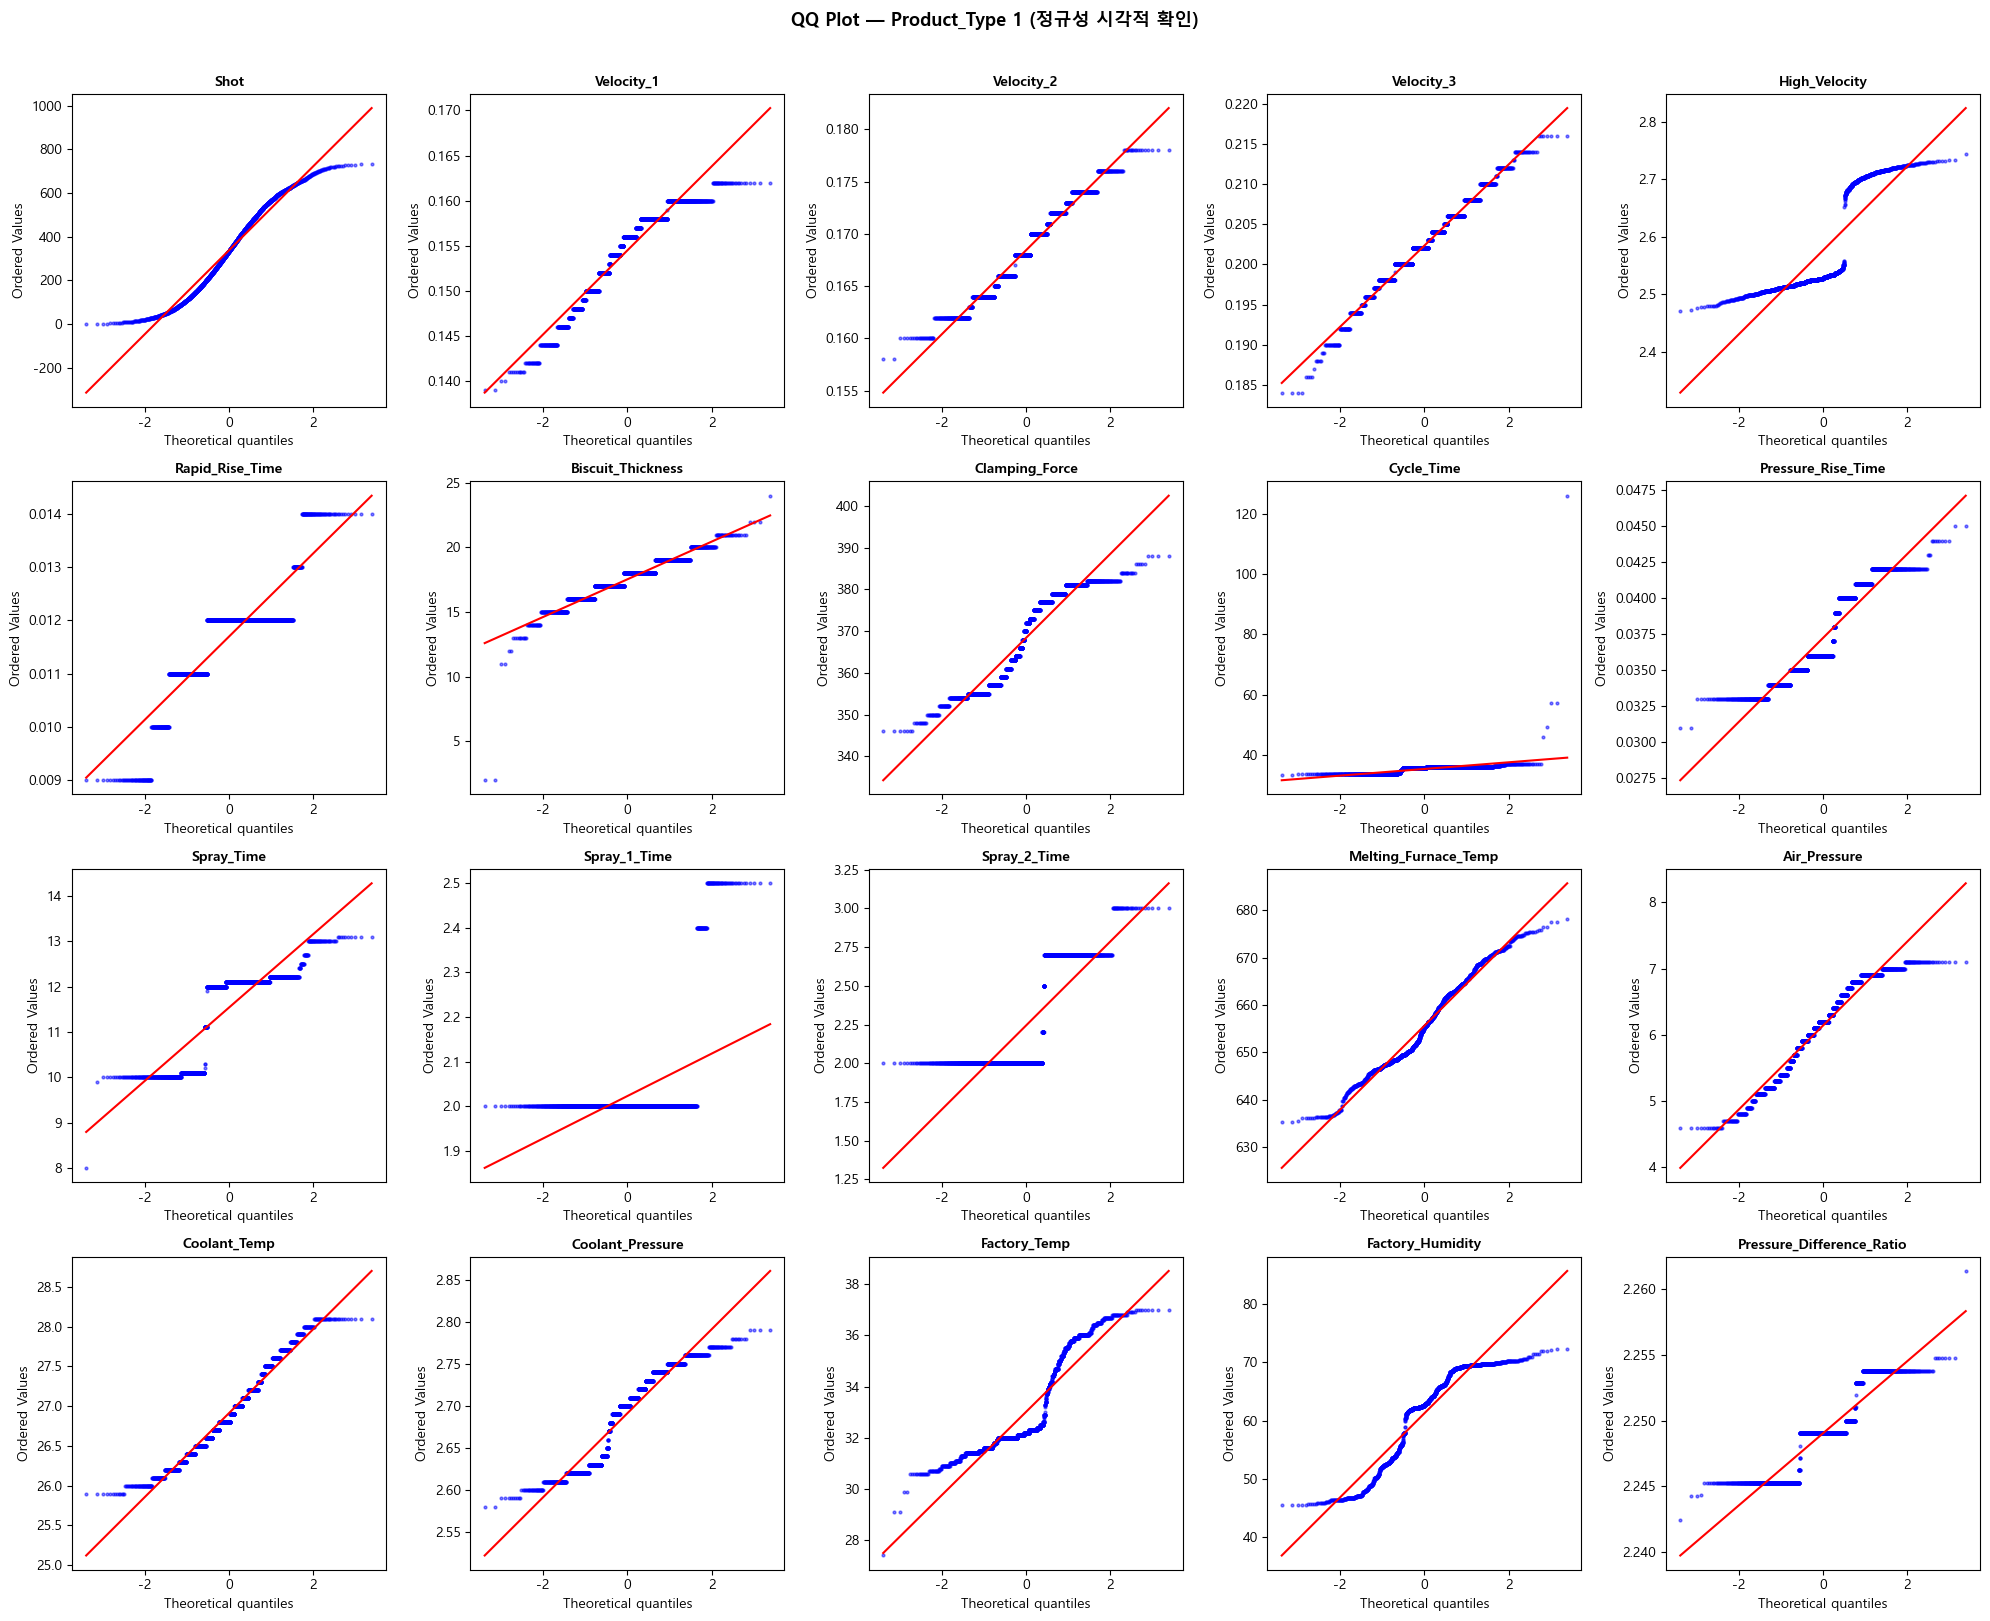

In [57]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import math

n_vars = len(independent_columns)
n_cols = 5
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(independent_columns):
    stats.probplot(type2_df[col].dropna(), dist="norm", plot=axes[i])
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].get_lines()[0].set(markersize=2, alpha=0.5)

# 남는 빈 서브플롯 숨기기
for j in range(n_vars, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('QQ Plot — Product_Type 1 (정규성 시각적 확인)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [58]:
from scipy.stats import spearmanr

results = []

for col in type2_df[independent_columns]:
    clean = type2_df[[col, 'Defect_Status']].dropna()
    corr, p = spearmanr(clean[col], clean['Defect_Status'])
    results.append({
        '변수': col,
        '스피어만 상관계수': round(corr, 4),
        'p-value': round(p, 4),
        '절댓값': round(abs(corr), 4)
})

spearman_df = pd.DataFrame(results).sort_values('절댓값', ascending=False)
spearman_df

,변수,스피어만 상관계수,p-value,절댓값
4,High_Velocity,0.2333,0.0000,0.2333
17,Factory_Temp,0.2010,0.0000,0.2010
12,Spray_2_Time,0.1881,0.0000,0.1881
7,Clamping_Force,-0.1657,0.0000,0.1657
10,Spray_Time,-0.1654,0.0000,0.1654
16,Coolant_Pressure,-0.1582,0.0000,0.1582
9,Pressure_Rise_Time,0.1454,0.0000,0.1454
18,Factory_Humidity,-0.1265,0.0000,0.1265
8,Cycle_Time,-0.1198,0.0000,0.1198
15,Coolant_Temp,0.0966,0.0000,0.0966


### Mann-Whitney U 검정

In [59]:
from scipy.stats import mannwhitneyu

defect   = type2_df[type2_df['Defect_Status'] == 1]
normal   = type2_df[type2_df['Defect_Status'] == 0]

results = []
for col in independent_columns:
    stat, p = mannwhitneyu(
        defect[col].dropna(),
        normal[col].dropna(),
        alternative='two-sided'
    )
    results.append({
        '변수': col,
        'U통계량': round(stat, 1),
        'p-value': round(p, 4),
        '유의성': '✅' if p < 0.05 else '❌'
    })

result_df = pd.DataFrame(results).sort_values('p-value')
display(result_df)

,변수,U통계량,p-value,유의성
7,Clamping_Force,284565.0000,0.0000,✅
4,High_Velocity,477468.5000,0.0000,✅
9,Pressure_Rise_Time,434151.0000,0.0000,✅
15,Coolant_Temp,411221.5000,0.0000,✅
12,Spray_2_Time,440397.0000,0.0000,✅
10,Spray_Time,286913.5000,0.0000,✅
8,Cycle_Time,307185.0000,0.0000,✅
16,Coolant_Pressure,288216.0000,0.0000,✅
17,Factory_Temp,461586.0000,0.0000,✅
18,Factory_Humidity,303317.0000,0.0000,✅


### 효과크기 계산 (Rank-Biserial Correlation)

In [60]:
from scipy.stats import mannwhitneyu
import numpy as np

def rank_biserial(u_stat, n1, n2):
    return (2 * u_stat) / (n1 * n2) - 1

defect = type2_df[type2_df['Defect_Status'] == 1]
normal = type2_df[type2_df['Defect_Status'] == 0]
n1, n2 = len(defect), len(normal)

results = []
for col in independent_columns:
    stat, p = mannwhitneyu(defect[col].dropna(), normal[col].dropna(), alternative='two-sided')
    r = abs(rank_biserial(stat, n1, n2))
    results.append({
        '변수': col,
        'p-value': round(p, 4),
        '효과크기(r)': round(r, 4),
        '해석': '대' if r >= 0.5 else '중' if r >= 0.3 else '소'
    })

result_df = pd.DataFrame(results).sort_values('효과크기(r)', ascending=False)
display(result_df)

,변수,p-value,효과크기(r),해석
4,High_Velocity,0.0000,0.3097,중
17,Factory_Temp,0.0000,0.2662,소
7,Clamping_Force,0.0000,0.2194,소
10,Spray_Time,0.0000,0.2130,소
16,Coolant_Pressure,0.0000,0.2094,소
12,Spray_2_Time,0.0000,0.2081,소
9,Pressure_Rise_Time,0.0000,0.1909,소
18,Factory_Humidity,0.0000,0.1680,소
8,Cycle_Time,0.0000,0.1574,소
15,Coolant_Temp,0.0000,0.1280,소


### Kruskal-Wallis H 검정 (Defect_Type 별 차이 확인)

In [62]:
from scipy.stats import kruskal
import pandas as pd

results = []

# 결측치가 없으므로 고유한 결함 유형을 바로 추출
defect_types = type2_df['Defect_Type'].dropna().unique()

print(f"✅ 분석 대상 결함 유형: {defect_types}\n")

for col in independent_columns:
    # 각 결함 유형별로 해당 컬럼의 데이터 그룹 리스트 생성
    groups = [type2_df[type2_df['Defect_Type'] == dt][col] for dt in defect_types]
    
    # 조건 확인 없이 바로 Kruskal-Wallis 검정 실행
    stat, p = kruskal(*groups)
    
    results.append({
        '변수': col,
        'H통계량': round(stat, 2),
        'p-value': round(p, 2),
        '유의성': '✅' if p < 0.05 else '❌'
    })

# 데이터프레임 변환 후 p-value를 기준으로 오름차순 정렬
result_df = pd.DataFrame(results).sort_values('p-value')

result_df

✅ 분석 대상 결함 유형: <StringArray>
['Normal', 'Other', 'Short_Shot', 'Blow_Hole', 'Bubble', 'Stain']
Length: 6, dtype: str



,변수,H통계량,p-value,유의성
0,Shot,23.8600,0.0000,✅
3,Velocity_3,21.3700,0.0000,✅
7,Clamping_Force,119.1600,0.0000,✅
4,High_Velocity,208.0500,0.0000,✅
12,Spray_2_Time,185.2300,0.0000,✅
10,Spray_Time,120.4100,0.0000,✅
9,Pressure_Rise_Time,106.8100,0.0000,✅
8,Cycle_Time,81.7700,0.0000,✅
15,Coolant_Temp,28.9500,0.0000,✅
13,Melting_Furnace_Temp,41.0200,0.0000,✅


### 효과크기 계산 (Epsilon-squared)

In [63]:
results = []

# type1_df['Defect_Type'] 컬럼에서 결측치를 제외한 유니크(고유)한 결함 유형들을 자동으로 추출
defect_types = type2_df['Defect_Type'].dropna().unique()

for col in independent_columns:
    # 각 독립변수(col)에 대해 결측치(결측값)를 제외한 전체 데이터 수 (효과 크기 계산용)
    # 전체 n_total을 type1_df의 길이로 쓰면 결측치가 많은 변수에서 효과크기가 부정확해질 수 있으므로,
    # 해당 변수(col) 기준에서의 유효한 데이터 개수를 세는 것이 더 정확합니다.
    col_valid_data = type2_df[~type2_df['Defect_Type'].isna()][col].dropna()
    n_total = len(col_valid_data)
    
    # 동적으로 추출한 defect_types를 바탕으로 각각의 그룹 데이터 리스트 생성
    groups = [
        type2_df[type2_df['Defect_Type'] == dt][col].dropna() 
        for dt in defect_types
    ]
    
    # 길이가 0인 그룹 제외
    valid_groups = [g for g in groups if len(g) > 0]
    
    # Kruskal-Wallis 검정 및 효과 크기 계산
    if len(valid_groups) >= 2 and n_total > 1:
        stat, p = kruskal(*valid_groups)
        
        # Epsilon-squared 계산 공식: H / (n^2 - 1) * (n + 1) -> H / (n - 1)
        eps_sq = stat / (n_total - 1)
        
        results.append({
            '변수': col,
            'H통계량': round(stat, 2),
            'p-value': round(p, 4),
            'ε²': round(eps_sq, 4),
            '해석': '대' if eps_sq >= 0.14 else '중' if eps_sq >= 0.06 else '소'
        })
    else:
        results.append({
            '변수': col,
            'H통계량': None,
            'p-value': '비교 그룹 부족 또는 데이터 부족',
            'ε²': None,
            '해석': '-'
        })

result_df = pd.DataFrame(results)

# ε²(에타 제곱)을 기준으로 내림차순 정렬 (결측치(None) 대비 안전하게 정렬)
result_df = result_df.sort_values(by='ε²', ascending=False, na_position='last')

result_df

,변수,H통계량,p-value,ε²,해석
4,High_Velocity,208.0500,0.0000,0.1060,중
17,Factory_Temp,196.5900,0.0000,0.1001,중
12,Spray_2_Time,185.2300,0.0000,0.0944,중
18,Factory_Humidity,140.8700,0.0000,0.0718,중
16,Coolant_Pressure,137.8400,0.0000,0.0702,중
10,Spray_Time,120.4100,0.0000,0.0613,중
7,Clamping_Force,119.1600,0.0000,0.0607,중
9,Pressure_Rise_Time,106.8100,0.0000,0.0544,소
8,Cycle_Time,81.7700,0.0000,0.0417,소
13,Melting_Furnace_Temp,41.0200,0.0000,0.0209,소


### 사후검정 (Dunn's Test)

In [65]:
import scikit_posthocs as sp
import pandas as pd
import numpy as np

# 앞서 정의했던 분석 대상 결함군 리스트 자동 추출
defect_types = type2_df['Defect_Type'].dropna().unique()

# final_vars 대신 independent_columns (또는 유의미하게 나온 변수 리스트)를 순회하도록 변경
for col in independent_columns:
    print(f'\n--- {col} ---')
    
    # 1. 해당 독립변수(col)와 그룹변수(Defect_Type)에 결측치가 없는 데이터만 1차로 필터링
    # Dunn's Test는 결측치가 그룹에 엉켜있으면 잘못된 자유도/결과를 낼 수 있음
    valid_df = type2_df[[col, 'Defect_Type']].dropna()
    
    # 2. 방금 추출한 defect_types에 해당하는 데이터인지 한 번 더 명확히 확인
    valid_df = valid_df[valid_df['Defect_Type'].isin(defect_types)]
        
    # 3. Dunn's Test 수행
    dunn = sp.posthoc_dunn(
        valid_df,
        val_col=col,
        group_col='Defect_Type',
        p_adjust='bonferroni'
    )
    
    # 결과를 읽기 편하게 4자리 반올림 (너무 작은 값은 지수 표현이 아닌 0.0000으로 표시 됨)
    # 만약 이 표에서도 0.0000보다 더 자세히 보고 싶다면 round(4)를 지우셔도 됩니다.
    print(dunn.round(4))


--- Shot ---
            Blow_Hole  Bubble  Normal  Other  Short_Shot  Stain
Blow_Hole      1.0000  1.0000  1.0000 1.0000      1.0000 0.0007
Bubble         1.0000  1.0000  1.0000 1.0000      1.0000 1.0000
Normal         1.0000  1.0000  1.0000 1.0000      0.9200 0.0003
Other          1.0000  1.0000  1.0000 1.0000      1.0000 0.0889
Short_Shot     1.0000  1.0000  0.9200 1.0000      1.0000 0.0000
Stain          0.0007  1.0000  0.0003 0.0889      0.0000 1.0000

--- Velocity_1 ---
            Blow_Hole  Bubble  Normal  Other  Short_Shot  Stain
Blow_Hole      1.0000  1.0000  1.0000 1.0000      1.0000 1.0000
Bubble         1.0000  1.0000  1.0000 1.0000      1.0000 1.0000
Normal         1.0000  1.0000  1.0000 1.0000      1.0000 1.0000
Other          1.0000  1.0000  1.0000 1.0000      1.0000 1.0000
Short_Shot     1.0000  1.0000  1.0000 1.0000      1.0000 1.0000
Stain          1.0000  1.0000  1.0000 1.0000      1.0000 1.0000

--- Velocity_2 ---
            Blow_Hole  Bubble  Normal  Other  Shor

In [67]:
defect_types

<StringArray>
['Normal', 'Other', 'Short_Shot', 'Blow_Hole', 'Bubble', 'Stain']
Length: 6, dtype: str

In [68]:
independent_columns

['Shot',
 'Velocity_1',
 'Velocity_2',
 'Velocity_3',
 'High_Velocity',
 'Rapid_Rise_Time',
 'Biscuit_Thickness',
 'Clamping_Force',
 'Cycle_Time',
 'Pressure_Rise_Time',
 'Spray_Time',
 'Spray_1_Time',
 'Spray_2_Time',
 'Melting_Furnace_Temp',
 'Air_Pressure',
 'Coolant_Temp',
 'Coolant_Pressure',
 'Factory_Temp',
 'Factory_Humidity',
 'Pressure_Difference_Ratio']

### 사후검정 결과 시각화 (Heatmap)


--- [ Pressure_Difference_Ratio ] 사후검정 p-value 히트맵 ---


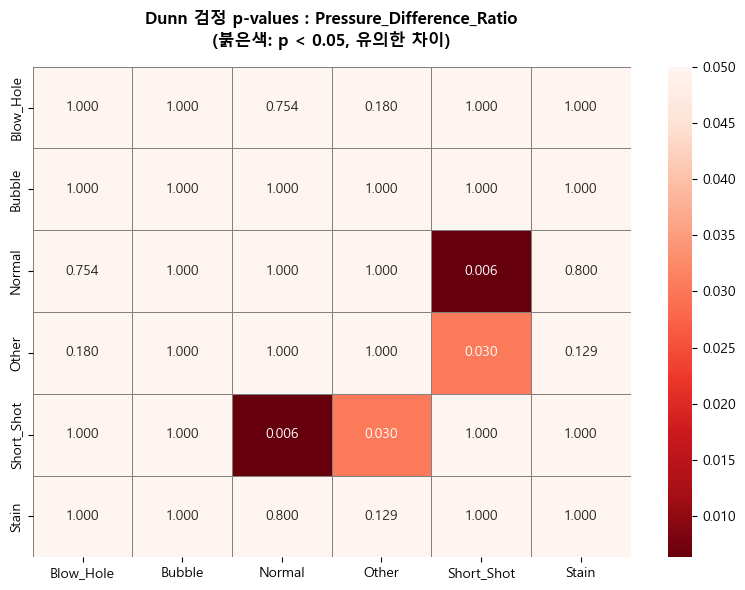

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 모든 컬럼에 대해 시각화하면 그래프가 너무 많아지므로,
# 위에서 사후검정을 돌렸던 independent_columns 중,
# 보고자 하는 특정 변수(col)를 하나 골라서 시각화하는 예시입니다.
# 여기서는 independent_columns의 첫 번째 변수를 예시로 가져옵니다.
col_to_visualize = independent_columns[19] # 원하는 변수로 변경 가능 (예: 'Velocity_1', 'Cycle_Time' 등)

print(f'\n--- [ {col_to_visualize} ] 사후검정 p-value 히트맵 ---')

# 해당 변수에 대해 다시 한 번 Dunn's Test 계산 (시각화용)
valid_df = type2_df[[col_to_visualize, 'Defect_Type']].dropna()
valid_df = valid_df[valid_df['Defect_Type'].isin(defect_types)]


dunn_matrix = sp.posthoc_dunn(
    valid_df,
    val_col=col_to_visualize,
    group_col='Defect_Type',
    p_adjust='bonferroni'
)

# 히트맵 그리기
plt.figure(figsize=(8, 6))

# 0.05 기준선 강조를 위해 마스킹 처리 (선택사항)
# p-value가 0.05 미만인 곳은 색을 칠하고, 0.05 이상인 곳은 하얗게 둡니다.
# sns.heatmap의 파라미터로 mask를 쓰거나 색상 팔레트를 조절합니다.

# 색상맵 설정 (p-value는 작을수록 유의함 -> 작은 값을 붉은색으로 강조)
# 0에 가까우면 진한 빨강, 0.05를 넘어가면 하얀색(파란색)으로 표현
cmap = sns.color_palette("Reds_r", as_cmap=True) # Reds_r 은 빨간색을 뒤집어 0에 가까울수록 진하게

# annot=True 로 숫자 표시, fmt='.3f' 로 소수점 3자리 표시
ax = sns.heatmap(dunn_matrix, annot=True, cmap=cmap, fmt=".3f", 
                    vmax=0.05,  # 0.05를 최대치로 잡아 그 이상은 유의하지 않은 것으로 처리
                    linewidths=0.5, linecolor='gray')

plt.title(f"Dunn 검정 p-values : {col_to_visualize}\n(붉은색: p < 0.05, 유의한 차이)", 
            fontweight='bold', pad=15)
plt.tight_layout()
plt.show()